# Lecture 2: Variational Autoencoders (VAEs) from Scratch

<div class="nav-links">
  <a href="../../intro.html">About Me</a>
  <a href="../../publications.html">Publications</a>
  <a href="../../course_notes/my-teaching-philosophy.html">My Teaching</a>
  <a href="../../research_notes/intro.html">Research Notes</a>
</div>

This notebook develops **Variational Autoencoders (VAEs)** from first principles.

We will cover:

1. The probabilistic prerequisites required for VAEs
2. Latent variable models
3. Why maximum likelihood becomes difficult
4. Variational inference and the approximate posterior
5. Full derivation of the ELBO
6. Expansion of the ELBO into reconstruction and KL terms
7. Why the reconstruction term becomes BCE or MSE depending on the decoder likelihood
8. The reparameterization trick
9. How encoder and decoder are trained jointly
10. Visual plots and code demonstrations for key concepts


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import math

# Optional: make plots a bit larger and cleaner
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

rng = np.random.default_rng(42)

## 1. High-Level Overview of VAEs

A **Variational Autoencoder (VAE)** is a **latent variable generative model**.

It assumes that observed data $x$ is generated using a hidden latent variable $z$:

$$
z \sim p(z), \qquad x \sim p_\theta(x \mid z)
$$

where:

- $z$ is a latent variable
- $p(z)$ is the prior over latents, usually a simple distribution such as $\mathcal{N}(0, I)$
- $p_\theta(x \mid z)$ is the decoder or generative model
- $\theta$ are the decoder parameters

The goals of a VAE are:

1. Learn a probabilistic generative model of the data
2. Learn meaningful latent representations
3. Enable generation of new samples by sampling $z \sim p(z)$ and decoding it

The central difficulty is that learning requires the marginal likelihood

$$
p_\theta(x) = \int p_\theta(x, z)\,dz = \int p(z)\,p_\theta(x \mid z)\,dz
$$

and this integral is generally intractable when $p_\theta(x \mid z)$ is parameterized by a neural network.

That is why we need **variational inference**.

## 2. Probabilistic Prerequisites

Before deriving VAEs, we need a few mathematical ingredients:

- probability densities
- Gaussian distributions
- expectations
- log-likelihood
- KL divergence
- Jensen's inequality
- latent variable models
- posterior inference

### 2.1 Probability Densities

For continuous random variables, probability is defined through a density.

If $x$ has density $p(x)$, then for any region $A$,

$$
\mathbb{P}(x \in A) = \int_A p(x)\,dx
$$

For two random variables $x$ and $z$, the joint density is $p(x, z)$, and we can write

$$
p(x, z) = p(x \mid z)p(z) = p(z \mid x)p(x)
$$

The marginal density of $x$ is

$$
p(x) = \int p(x, z)\,dz
$$

and the posterior is

$$
p(z \mid x) = \frac{p(x, z)}{p(x)}
$$

### 2.2 Gaussian Distribution

A univariate Gaussian is

$$
\mathcal{N}(x; \mu, \sigma^2)
=
\frac{1}{\sqrt{2\pi \sigma^2}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right)
$$

A multivariate Gaussian in $d$ dimensions is

$$
\mathcal{N}(x; \mu, \Sigma)
=
\frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}}
\exp\left(
-\frac{1}{2}(x-\mu)^T \Sigma^{-1} (x-\mu)
\right)
$$

A common VAE encoder uses a **diagonal Gaussian**:

$$
q_\phi(z \mid x)
=
\mathcal{N}\bigl(z;\mu_\phi(x), \operatorname{diag}(\sigma_\phi^2(x))\bigr)
$$

This means the encoder outputs:

- a mean vector $\mu_\phi(x)$
- a variance vector $\sigma_\phi^2(x)$

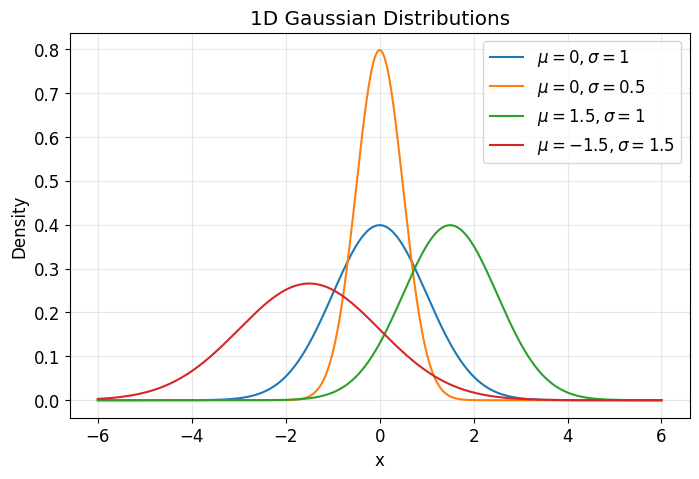

In [16]:
def gaussian_pdf_1d(x, mu, sigma):
    return (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

x = np.linspace(-6, 6, 500)

plt.figure()

for mu, sigma in [(0, 1), (0, 0.5), (1.5, 1), (-1.5, 1.5)]:
    plt.plot(x, gaussian_pdf_1d(x, mu, sigma), label=fr"$\mu={mu}, \sigma={sigma}$")
    
plt.title("1D Gaussian Distributions")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The plot above helps build intuition:

- changing $\mu$ shifts the distribution
- changing $\sigma$ changes spread or uncertainty

This becomes important in VAEs because the encoder maps each datapoint $x$ to a Gaussian distribution in latent space.

### 2.3 Expectation

For a random variable $z \sim q(z)$ and a function $f(z)$, the expectation is

$$
\mathbb{E}_{q(z)}[f(z)] = \int q(z) f(z)\,dz
$$

For discrete variables,

$$
\mathbb{E}_{q(z)}[f(z)] = \sum_z q(z) f(z)
$$

Expectation is simply the average value of $f(z)$ under the distribution $q(z)$.

In [17]:
samples = rng.normal(loc=2.0, scale=1.5, size=100000)
empirical_mean = np.mean(samples)
empirical_second_moment = np.mean(samples**2)

print("Empirical E[z]      =", empirical_mean)
print("Empirical E[z^2]    =", empirical_second_moment)
print("Theoretical E[z]    =", 2.0)
print("Theoretical E[z^2]  =", 1.5**2 + 2.0**2)

Empirical E[z]      = 1.993650604581616
Empirical E[z^2]    = 6.241338452290414
Theoretical E[z]    = 2.0
Theoretical E[z^2]  = 6.25


The code above illustrates that expectation can be approximated using samples.  
This is important because in VAEs the reconstruction term contains an expectation over $q_\phi(z \mid x)$, which we often approximate using Monte Carlo sampling.

### 2.4 Log-Likelihood

For a probabilistic model, we often want to maximize likelihood:

$$
p_\theta(x)
$$

or equivalently maximize log-likelihood:

$$
\log p_\theta(x)
$$

We prefer log-likelihood because:

1. it converts products into sums
2. it is numerically more stable
3. maximizing $\log p_\theta(x)$ is equivalent to maximizing $p_\theta(x)$ since $\log$ is monotonic

For a dataset $\{x^{(i)}\}_{i=1}^N$, maximum likelihood estimation solves

$$
\max_\theta \sum_{i=1}^N \log p_\theta(x^{(i)})
$$

### 2.5 KL Divergence

The KL divergence from $q(z)$ to $p(z)$ is

$$
D_{\mathrm{KL}}(q(z)\|p(z))
=
\int q(z)\log\frac{q(z)}{p(z)}\,dz
=
\mathbb{E}_{q(z)}\left[\log \frac{q(z)}{p(z)}\right]
$$

Important properties:

- $D_{\mathrm{KL}}(q\|p) \ge 0$
- $D_{\mathrm{KL}}(q\|p) = 0$ if and only if $q = p$ almost everywhere
- it is not symmetric

In VAEs, the KL term measures how far the encoder posterior $q_\phi(z \mid x)$ is from the prior $p(z)$.

For two Gaussians where

$$
q(z) = \mathcal{N}(\mu, \Sigma), \qquad p(z) = \mathcal{N}(0, I)
$$

the KL divergence is

$$
D_{\mathrm{KL}}(q\|p)
=
\frac{1}{2}
\left(
\operatorname{tr}(\Sigma) + \mu^T\mu - k - \log |\Sigma|
\right)
$$

where $k$ is the dimension of $z$.

If $\Sigma = \operatorname{diag}(\sigma_1^2, \dots, \sigma_k^2)$, then

$$
D_{\mathrm{KL}}(q\|p)
=
\frac{1}{2}
\sum_{j=1}^k
\left(
\mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1
\right)
$$

This is the standard closed-form VAE KL term.

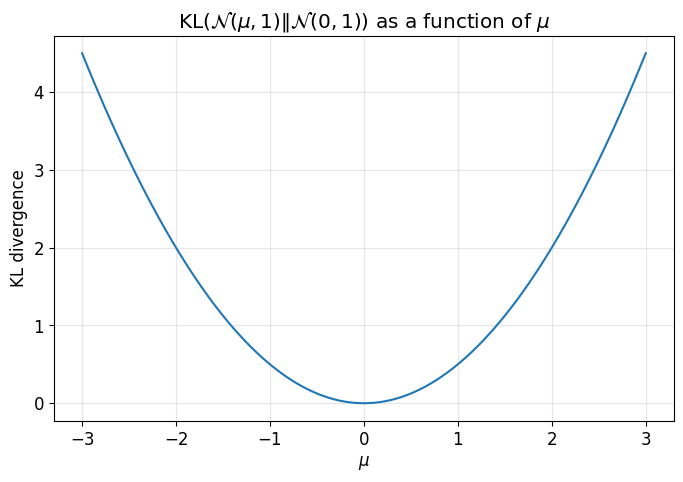

In [18]:
def kl_diag_gaussian_to_standard_normal(mu, logvar):
    """
    mu: array-like, shape (..., d)
    logvar: array-like, shape (..., d)
    returns KL for each sample
    """
    return 0.5 * np.sum(np.exp(logvar) + mu**2 - 1.0 - logvar, axis=-1)

mu_values = np.linspace(-3, 3, 300)
logvar_fixed = np.zeros((300, 1))  # variance = 1
mu_grid = mu_values.reshape(-1, 1)

kl_vals = kl_diag_gaussian_to_standard_normal(mu_grid, logvar_fixed)

plt.figure()
plt.plot(mu_values, kl_vals)
plt.title(r"KL$(\mathcal{N}(\mu,1)\|\mathcal{N}(0,1))$ as a function of $\mu$")
plt.xlabel(r"$\mu$")
plt.ylabel("KL divergence")
plt.grid(True, alpha=0.3)
plt.show()

This plot shows that the KL divergence grows as the encoder mean moves away from the prior mean $0$.

That is one way the KL term regularizes the latent space.

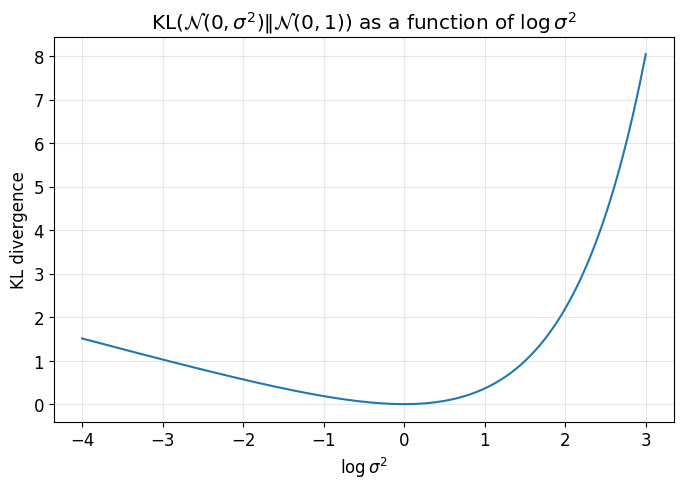

In [19]:
logvar_values = np.linspace(-4, 3, 300)
mu_fixed = np.zeros((300, 1))
logvar_grid = logvar_values.reshape(-1, 1)

kl_vals_var = kl_diag_gaussian_to_standard_normal(mu_fixed, logvar_grid)

plt.figure()
plt.plot(logvar_values, kl_vals_var)
plt.title(r"KL$(\mathcal{N}(0,\sigma^2)\|\mathcal{N}(0,1))$ as a function of $\log \sigma^2$")
plt.xlabel(r"$\log \sigma^2$")
plt.ylabel("KL divergence")
plt.grid(True, alpha=0.3)
plt.show()

This second plot shows that the KL divergence is minimized when $\sigma^2 = 1$, i.e. when $\log \sigma^2 = 0$.

So the KL term encourages both:

- mean near $0$
- variance near $1$

### 2.6 Jensen's Inequality

For a concave function $f$,

$$
f(\mathbb{E}[X]) \ge \mathbb{E}[f(X)]
$$

Since $\log$ is concave,

$$
\log \mathbb{E}[X] \ge \mathbb{E}[\log X]
$$

This is the key inequality used to derive the ELBO as a lower bound.

In [20]:
# Simple illustration of Jensen's inequality for log
positive_samples = rng.uniform(0.1, 5.0, size=100000)

lhs = np.log(np.mean(positive_samples))
rhs = np.mean(np.log(positive_samples))

print("log(E[X]) =", lhs)
print("E[log X]  =", rhs)
print("Difference log(E[X]) - E[log X] =", lhs - rhs)

log(E[X]) = 0.9341878920756458
E[log X]  = 0.6874473352543539
Difference log(E[X]) - E[log X] = 0.24674055682129192


The output confirms:

$$
\log \mathbb{E}[X] \ge \mathbb{E}[\log X]
$$

This is exactly why the ELBO becomes a lower bound on $\log p_\theta(x)$.

## 3. Latent Variable Models

A latent variable model introduces hidden variables $z$ to explain observed data $x$.

The model is

$$
p_\theta(x, z) = p(z)\,p_\theta(x \mid z)
$$

and the marginal likelihood of a datapoint is

$$
p_\theta(x) = \int p_\theta(x, z)\,dz = \int p(z)\,p_\theta(x \mid z)\,dz
$$

The latent variable $z$ is intended to capture underlying structure that helps explain the data.

### Why is exact maximum likelihood hard?

We would ideally like to maximize

$$
\log p_\theta(x) = \log \int p(z)\,p_\theta(x \mid z)\,dz
$$

The problem is:

- the integral over $z$ is generally intractable
- the posterior

$$
p_\theta(z \mid x) = \frac{p_\theta(x, z)}{p_\theta(x)}
$$

is also intractable because it depends on the same marginal $p_\theta(x)$

So the model is elegant, but exact learning and inference are hard.

### Variational Inference Idea

To deal with the intractable posterior, we introduce an approximation:

$$
q_\phi(z \mid x)
$$

where:

- $\phi$ are encoder parameters
- $q_\phi(z \mid x)$ is chosen to be tractable
- we want it to approximate the true posterior $p_\theta(z \mid x)$

The central idea of VAEs is to optimize a tractable lower bound on $\log p_\theta(x)$.

## 4. Autoencoder vs Variational Autoencoder

A classical autoencoder does:

$$
h = f_\phi(x), \qquad \hat{x} = g_\theta(h)
$$

It learns a deterministic latent code $h$.

A VAE instead learns a **distribution** over latent codes:

$$
q_\phi(z \mid x)
$$

and then samples

$$
z \sim q_\phi(z \mid x)
$$

before decoding through

$$
p_\theta(x \mid z)
$$

So the VAE is probabilistic, and therefore generative.

## 5. ELBO Derivation from Scratch

We begin with the log marginal likelihood:

$$
\log p_\theta(x)
$$

We now multiply and divide by $q_\phi(z \mid x)$ inside the integral:

$$
\log p_\theta(x)
=
\log \int q_\phi(z \mid x)\,\frac{p_\theta(x, z)}{q_\phi(z \mid x)}\,dz
$$

Recognizing expectation under $q_\phi(z \mid x)$, we get

$$
\log p_\theta(x)
=
\log
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\frac{p_\theta(x, z)}{q_\phi(z \mid x)}
\right]
$$

Now apply Jensen's inequality:

$$
\log
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\frac{p_\theta(x, z)}{q_\phi(z \mid x)}
\right]
\ge
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log
\frac{p_\theta(x, z)}{q_\phi(z \mid x)}
\right]
$$

Therefore,

$$
\log p_\theta(x)
\ge
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log p_\theta(x, z) - \log q_\phi(z \mid x)
\right]
$$

This lower bound is called the **Evidence Lower Bound (ELBO)**:

$$
\mathcal{L}(x;\theta,\phi)
=
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log p_\theta(x, z) - \log q_\phi(z \mid x)
\right]
$$

So the ELBO is

$$
\boxed{
\mathcal{L}(x;\theta,\phi)
=
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log p_\theta(x, z) - \log q_\phi(z \mid x)
\right]
}
$$

and it satisfies

$$
\mathcal{L}(x;\theta,\phi) \le \log p_\theta(x)
$$

## 6. ELBO Derivation Using the True Posterior

Now let us derive the same result in a way that makes the role of the posterior approximation clearer.

Consider the KL divergence between the approximate posterior and the true posterior:

$$
D_{\mathrm{KL}}\bigl(q_\phi(z \mid x)\|p_\theta(z \mid x)\bigr)
=
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log \frac{q_\phi(z \mid x)}{p_\theta(z \mid x)}
\right]
$$

Using Bayes' rule,

$$
p_\theta(z \mid x) = \frac{p_\theta(x, z)}{p_\theta(x)}
$$

So,

$$
D_{\mathrm{KL}}\bigl(q_\phi(z \mid x)\|p_\theta(z \mid x)\bigr)
=
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log q_\phi(z \mid x) - \log p_\theta(x, z) + \log p_\theta(x)
\right]
$$

Since $\log p_\theta(x)$ does not depend on $z$,

$$
D_{\mathrm{KL}}\bigl(q_\phi(z \mid x)\|p_\theta(z \mid x)\bigr)
=
\log p_\theta(x)
+
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log q_\phi(z \mid x) - \log p_\theta(x, z)
\right]
$$

Rearranging,

$$
\log p_\theta(x)
=
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log p_\theta(x, z) - \log q_\phi(z \mid x)
\right]
+
D_{\mathrm{KL}}\bigl(q_\phi(z \mid x)\|p_\theta(z \mid x)\bigr)
$$

Therefore,

$$
\boxed{
\log p_\theta(x)
=
\mathcal{L}(x;\theta,\phi)
+
D_{\mathrm{KL}}\bigl(q_\phi(z \mid x)\|p_\theta(z \mid x)\bigr)
}
$$

Since KL divergence is nonnegative,

$$
\mathcal{L}(x;\theta,\phi) \le \log p_\theta(x)
$$

and the bound becomes tight exactly when

$$
q_\phi(z \mid x) = p_\theta(z \mid x)
$$

## 7. Expanding the ELBO into the Standard VAE Form

Recall:

$$
\mathcal{L}(x;\theta,\phi)
=
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log p_\theta(x, z) - \log q_\phi(z \mid x)
\right]
$$

Since the joint factorizes as

$$
p_\theta(x, z) = p(z)\,p_\theta(x \mid z)
$$

we have

$$
\log p_\theta(x, z)
=
\log p(z) + \log p_\theta(x \mid z)
$$

Substituting this into the ELBO gives

$$
\mathcal{L}(x;\theta,\phi)
=
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log p_\theta(x \mid z) + \log p(z) - \log q_\phi(z \mid x)
\right]
$$

Split the expectation:

$$
\mathcal{L}(x;\theta,\phi)
=
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
+
\mathbb{E}_{q_\phi(z \mid x)}[\log p(z) - \log q_\phi(z \mid x)]
$$

The second term is exactly minus a KL divergence:

$$
\mathbb{E}_{q_\phi(z \mid x)}[\log p(z) - \log q_\phi(z \mid x)]
=
-
D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
$$

So the ELBO becomes

$$
\boxed{
\mathcal{L}(x;\theta,\phi)
=
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
-
D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
}
$$

This is the standard VAE objective.

It has two terms:

1. **Reconstruction term**

   $$
   \mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
   $$

   which encourages good reconstructions

2. **KL regularization term**

   $$
   D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
   $$
   
   which encourages the latent posterior to remain close to the prior

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

def plot_gaussian_ellipse(
    ax,
    mean,
    cov,
    n_std=2.0,
    linestyle='-',
    edgecolor='black',
    linewidth=2,
    label=None,
):
    """
    Plot a covariance ellipse for a 2D Gaussian.

    Parameters
    ----------
    ax : matplotlib axis
        Axis to draw on.
    mean : array-like of shape (2,)
        Mean of the Gaussian.
    cov : array-like of shape (2, 2)
        Covariance matrix.
    n_std : float
        Number of standard deviations for ellipse radius.
    linestyle : str
        Matplotlib line style, e.g. '-', '--'.
    edgecolor : str
        Ellipse outline color.
    linewidth : float
        Ellipse line width.
    """
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        edgecolor=edgecolor,
        linestyle=linestyle,
        linewidth=linewidth,
        label=label,
    )
    ax.add_patch(ellipse)


def make_latent_regularization_legend():
    """
    Create clean custom legend handles so prior and posterior
    are visually distinguishable.
    """
    handles = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label='Prior $p(z)$'),
        Line2D([0], [0], color='black', lw=2, linestyle='--', label='Approx posterior $q(z\\mid x)$'),
        Line2D([0], [0], marker='o', linestyle='None', label='Prior mean'),
        Line2D([0], [0], marker='o', linestyle='None', label='Posterior mean'),
    ]
    return handles

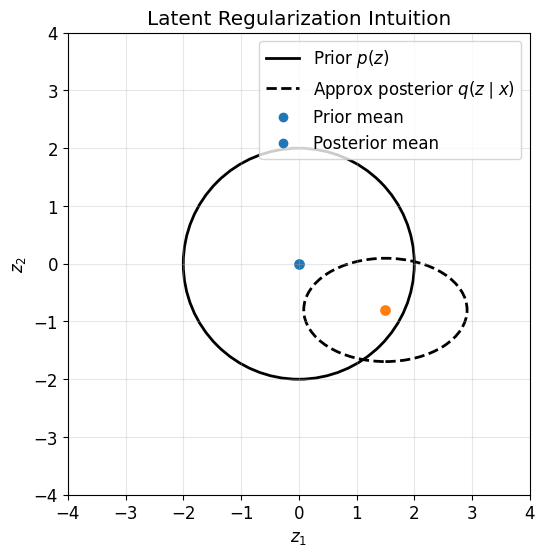

In [29]:
# Example parameters
prior_mean = np.array([0.0, 0.0])
prior_cov = np.array([
    [1.0, 0.0],
    [0.0, 1.0]
])

post_mean = np.array([1.5, -0.8])
post_cov = np.array([
    [0.5, 0.0],
    [0.0, 0.2]
])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

plot_gaussian_ellipse(
    ax=ax,
    mean=prior_mean,
    cov=prior_cov,
    n_std=2.0,
    linestyle='-',
    edgecolor='black',
    linewidth=2,
)

plot_gaussian_ellipse(
    ax=ax,
    mean=post_mean,
    cov=post_cov,
    n_std=2.0,
    linestyle='--',
    edgecolor='black',
    linewidth=2,
)

ax.scatter(*prior_mean, s=45)
ax.scatter(*post_mean, s=45)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect("equal")
ax.set_title("Latent Regularization Intuition")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.grid(True, alpha=0.3)

ax.legend(handles=make_latent_regularization_legend(), loc='upper right')

plt.show()

This figure illustrates the geometric role of the KL term.

- The prior $p(z)$ is centered at the origin with identity covariance
- The approximate posterior $q_\phi(z \mid x)$ for one datapoint may shift and shrink
- The KL term penalizes large deviations from the prior

Thus the KL term organizes the latent space so that different datapoints live in a shared, regularized structure.

## 8. Why Maximizing the ELBO Makes Sense

We ultimately want to maximize the true log-likelihood:

$$
\log p_\theta(x)
$$

But from the identity

$$
\log p_\theta(x)
=
\mathcal{L}(x;\theta,\phi)
+
D_{\mathrm{KL}}\bigl(q_\phi(z \mid x)\|p_\theta(z \mid x)\bigr)
$$

we see that maximizing the ELBO does two things:

1. it increases a lower bound on the true log-likelihood
2. it pushes the approximate posterior $q_\phi(z \mid x)$ toward the true posterior $p_\theta(z \mid x)$

So ELBO maximization is a principled surrogate for maximum likelihood learning.

## 9. Encoder and Decoder Parameterization

The encoder defines the approximate posterior:

$$
q_\phi(z \mid x)
=
\mathcal{N}\bigl(z; \mu_\phi(x), \operatorname{diag}(\sigma_\phi^2(x))\bigr)
$$

So for each input $x$, the encoder network outputs:

$$
\mu_\phi(x), \qquad \log \sigma_\phi^2(x)
$$

The decoder defines the conditional likelihood:

$$
p_\theta(x \mid z)
$$

Its exact form depends on the type of data:

- Bernoulli for binary data
- Gaussian for continuous data
- other likelihoods for other data types

So for each datapoint, the encoder maps $x$ not to a single point, but to a **distribution in latent space**.

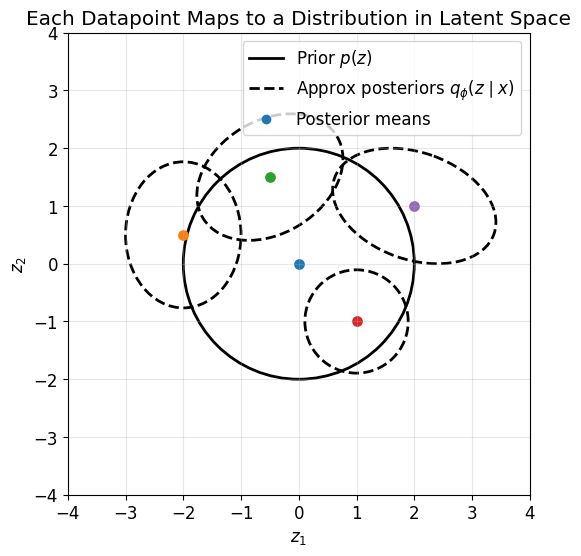

In [31]:
# Simulate "encoder outputs" for a few example datapoints in 2D latent space
means = np.array([
    [-2.0, 0.5],
    [-0.5, 1.5],
    [1.0, -1.0],
    [2.0, 1.0]
])

covs = [
    np.array([[0.25, 0.0], [0.0, 0.4]]),
    np.array([[0.4, 0.1], [0.1, 0.3]]),
    np.array([[0.2, 0.0], [0.0, 0.2]]),
    np.array([[0.5, -0.1], [-0.1, 0.25]])
]

fig, ax = plt.subplots(figsize=(6, 6))

# Prior
plot_gaussian_ellipse(
    ax=ax,
    mean=np.zeros(2),
    cov=np.eye(2),
    n_std=2.0,
    linestyle='-',
    edgecolor='black',
    linewidth=2,
)

ax.scatter(0, 0, s=45)

# Approximate posteriors for several datapoints
for m, c in zip(means, covs):
    plot_gaussian_ellipse(
        ax=ax,
        mean=m,
        cov=c,
        n_std=2.0,
        linestyle='--',
        edgecolor='black',
        linewidth=2,
    )
    ax.scatter(*m, s=45)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect("equal")
ax.set_title("Each Datapoint Maps to a Distribution in Latent Space")
ax.set_xlabel(r"$z_1$")
ax.set_ylabel(r"$z_2$")
ax.grid(True, alpha=0.3)

legend_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='-', label='Prior $p(z)$'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Approx posteriors $q_\\phi(z\\mid x)$'),
    Line2D([0], [0], marker='o', linestyle='None', label='Posterior means'),
]

ax.legend(handles=legend_handles, loc='upper right')

plt.show()

This plot gives an important conceptual picture:

- each datapoint $x$ is mapped by the encoder to a Gaussian
- different datapoints correspond to different posterior distributions
- the KL term prevents these from drifting arbitrarily far from the prior

## 10. The Reparameterization Trick

The reconstruction term contains an expectation over samples from the encoder distribution:

$$
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
$$

We want gradients with respect to encoder parameters $\phi$.

But naively sampling

$$
z \sim q_\phi(z \mid x)
$$

creates a stochastic node that is not directly amenable to standard backpropagation.

To fix this, we use the reparameterization trick.

If

$$
q_\phi(z \mid x)
=
\mathcal{N}\bigl(z;\mu_\phi(x), \operatorname{diag}(\sigma_\phi^2(x))\bigr)
$$

then we can sample by first drawing

$$
\epsilon \sim \mathcal{N}(0, I)
$$

and then setting

$$
\boxed{
z = \mu_\phi(x) + \sigma_\phi(x)\odot \epsilon
}
$$

Now the randomness is isolated in $\epsilon$, and $z$ is a differentiable function of the encoder outputs.

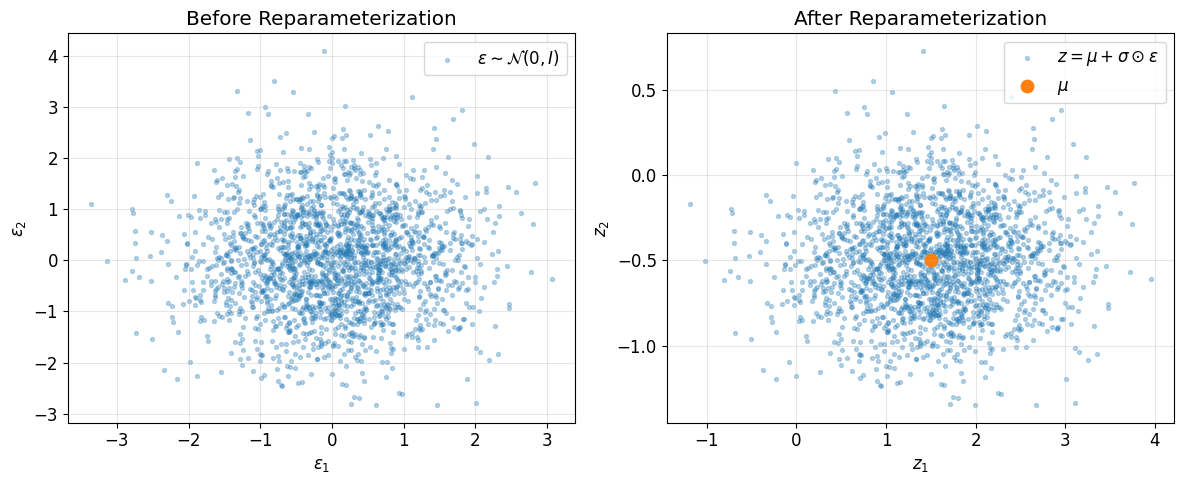

In [33]:
mu = np.array([1.5, -0.5])
sigma = np.array([0.8, 0.3])

eps = rng.normal(size=(2000, 2))
z_samples = mu + sigma * eps

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(eps[:, 0], eps[:, 1], s=8, alpha=0.3, label=r"$\epsilon \sim \mathcal{N}(0,I)$")
axes[0].set_title("Before Reparameterization")
axes[0].set_xlabel(r"$\epsilon_1$")
axes[0].set_ylabel(r"$\epsilon_2$")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].scatter(z_samples[:, 0], z_samples[:, 1], s=8, alpha=0.3, label=r"$z = \mu + \sigma \odot \epsilon$")
axes[1].scatter(*mu, s=80, label=r"$\mu$")
axes[1].set_title("After Reparameterization")
axes[1].set_xlabel(r"$z_1$")
axes[1].set_ylabel(r"$z_2$")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

These two plots show the reparameterization geometrically:

- first we sample standard Gaussian noise $\epsilon$
- then we shift and scale it using the encoder outputs
- this produces samples from the encoder posterior while keeping the computation differentiable

This is what allows gradients from the reconstruction term to flow back into the encoder.

## 11. Monte Carlo Approximation of the ELBO

The expectation term

$$
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
$$

is usually approximated using Monte Carlo samples.

Using the reparameterization trick, we write

$$
z^{(l)} = \mu_\phi(x) + \sigma_\phi(x)\odot \epsilon^{(l)},
\qquad
\epsilon^{(l)} \sim \mathcal{N}(0, I)
$$

Then

$$
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
\approx
\frac{1}{L}
\sum_{l=1}^{L}
\log p_\theta(x \mid z^{(l)})
$$

In practice, during minibatch training, we usually take $L=1$.

In [34]:
# Monte Carlo estimate of E[z^2] for z ~ N(mu, sigma^2)
mu = 1.0
sigma = 2.0

true_value = sigma**2 + mu**2
sample_sizes = [1, 5, 20, 100, 1000]
estimates = []

for n in sample_sizes:
    eps = rng.normal(size=n)
    z = mu + sigma * eps
    estimates.append(np.mean(z**2))

print("True E[z^2] =", true_value)
for n, est in zip(sample_sizes, estimates):
    print(f"MC estimate with {n:4d} samples = {est:.4f}")

True E[z^2] = 5.0
MC estimate with    1 samples = 1.2273
MC estimate with    5 samples = 8.6895
MC estimate with   20 samples = 9.0430
MC estimate with  100 samples = 4.6797
MC estimate with 1000 samples = 4.6531


This illustrates a general fact:

- expectations can be estimated using samples
- more samples usually reduce estimation noise
- in VAEs, even a single sample often works well enough for SGD training

## 12. Closed-Form KL Term Used in VAEs

For the common encoder choice

$$
q_\phi(z \mid x)
=
\mathcal{N}(z; \mu, \operatorname{diag}(\sigma^2))
$$

and prior

$$
p(z) = \mathcal{N}(0, I)
$$

the KL divergence is

$$
D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
=
\frac{1}{2}
\sum_{j=1}^{d}
\left(
\mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1
\right)
$$

If the network outputs $\log \sigma_j^2$, then since $\sigma_j^2 = e^{\log \sigma_j^2}$, the KL becomes

$$
D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
=
\frac{1}{2}
\sum_{j=1}^{d}
\left(
\mu_j^2 + e^{\log \sigma_j^2} - \log \sigma_j^2 - 1
\right)
$$

This is the exact formula implemented in most VAE code.

## 13. Why the Reconstruction Term Becomes BCE or MSE

The reconstruction term in the ELBO is

$$
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
$$

When we minimize negative ELBO, the reconstruction loss is

$$
-\log p_\theta(x \mid z)
$$

So the exact reconstruction loss depends entirely on the decoder likelihood.

### 13.1 Bernoulli Decoder

If the data is binary or normalized to $[0,1]$, one common choice is

$$
p_\theta(x \mid z)
=
\prod_{i=1}^{D}
\operatorname{Bernoulli}(x_i;\hat{x}_i(z))
$$

Then

$$
\log p_\theta(x \mid z)
=
\sum_{i=1}^{D}
\left[
x_i \log \hat{x}_i + (1-x_i)\log(1-\hat{x}_i)
\right]
$$

Therefore,

$$
-\log p_\theta(x \mid z)
=
\operatorname{BCE}(x,\hat{x})
$$

So a Bernoulli decoder leads to binary cross-entropy reconstruction loss.

### 13.2 Gaussian Decoder with Fixed Variance

If the data is continuous and we choose

$$
p_\theta(x \mid z)
=
\mathcal{N}(x;\mu_\theta(z), \sigma_x^2 I)
$$

with fixed $\sigma_x^2$, then

$$
\log p_\theta(x \mid z)
=
-\frac{D}{2}\log(2\pi \sigma_x^2)
-
\frac{1}{2\sigma_x^2}\|x-\mu_\theta(z)\|^2
$$

Thus,

$$
-\log p_\theta(x \mid z)
=
\frac{1}{2\sigma_x^2}\|x-\mu_\theta(z)\|^2 + \text{constant}
$$

If $\sigma_x^2$ is fixed, the constant does not affect optimization, so maximizing the likelihood is equivalent to minimizing mean squared error.

That is why MSE appears in many VAE implementations.

In [35]:
x_true = np.array([1.0, -0.5, 0.7])
xhat_candidates = np.array([
    [1.0, -0.5, 0.7],
    [0.8, -0.4, 0.9],
    [0.0,  0.0, 0.0],
    [2.0, -1.0, 1.4]
])

sigma2 = 0.25

def neg_log_gaussian_fixed_var(x, mu, sigma2):
    D = len(x)
    return 0.5 * D * np.log(2 * np.pi * sigma2) + (0.5 / sigma2) * np.sum((x - mu)**2)

print("Candidate reconstructions:")
for i, xhat in enumerate(xhat_candidates, 1):
    mse = np.mean((x_true - xhat)**2)
    nll = neg_log_gaussian_fixed_var(x_true, xhat, sigma2)
    print(f"{i}: MSE={mse:.4f}, Gaussian NLL={nll:.4f}")

Candidate reconstructions:
1: MSE=0.0000, Gaussian NLL=0.6774
2: MSE=0.0300, Gaussian NLL=0.8574
3: MSE=0.5800, Gaussian NLL=4.1574
4: MSE=0.5800, Gaussian NLL=4.1574


The printed values show that when variance is fixed, lower MSE corresponds directly to higher Gaussian likelihood.

So MSE is not an arbitrary reconstruction loss. It comes from a probabilistic Gaussian decoder assumption.

### 13.3 Gaussian Decoder with Learned Variance

If the decoder also predicts variance, then

$$
p_\theta(x \mid z)
=
\mathcal{N}(x;\mu_\theta(z), \operatorname{diag}(\sigma_\theta^2(z)))
$$

and the log-likelihood becomes

$$
\log p_\theta(x \mid z)
=
-\frac{1}{2}
\sum_{i=1}^{D}
\left[
\log(2\pi \sigma_{\theta,i}^2(z))
+
\frac{(x_i-\mu_{\theta,i}(z))^2}{\sigma_{\theta,i}^2(z)}
\right]
$$

This is no longer plain MSE.

Now the model can express uncertainty, and the loss includes:

- a weighted squared error term
- a log-variance penalty

### 13.4 Summary of Reconstruction Loss Choices

In general,

$$
\text{reconstruction loss} = -\log p_\theta(x \mid z)
$$

So:

- Bernoulli decoder $\rightarrow$ BCE
- Gaussian decoder with fixed variance $\rightarrow$ MSE up to constants
- Gaussian decoder with learned variance $\rightarrow$ weighted MSE plus variance penalty
- categorical decoder $\rightarrow$ cross-entropy

The reconstruction loss is therefore dictated by the decoder likelihood assumption.

## 14. Final VAE Training Loss

For one datapoint $x$, the ELBO is

$$
\mathcal{L}(x;\theta,\phi)
=
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
-
D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
$$

In practice we minimize the **negative ELBO**:

$$
\mathcal{J}(x;\theta,\phi)
=
-\mathcal{L}(x;\theta,\phi)
$$

So the training loss is

$$
\boxed{
\mathcal{J}(x;\theta,\phi)
=
-\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
+
D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
}
$$

For the standard Gaussian prior and diagonal Gaussian encoder,

$$
\boxed{
\mathcal{J}(x;\theta,\phi)
\approx
-\log p_\theta(x \mid z)
+
\frac{1}{2}\sum_{j=1}^{d}
\left(
\mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1
\right)
}
$$

where

$$
z = \mu_\phi(x) + \sigma_\phi(x)\odot \epsilon,
\qquad
\epsilon \sim \mathcal{N}(0,I)
$$

## 15. How Encoder and Decoder Are Trained Together

For one input $x$, the computation proceeds as follows:

1. The encoder computes

   $$
   \mu_\phi(x), \qquad \log \sigma_\phi^2(x)
   $$

2. Convert log variance to standard deviation:

   $$
   \sigma_\phi(x) = \exp\left(\frac{1}{2}\log \sigma_\phi^2(x)\right)
   $$

3. Sample noise:

   $$
   \epsilon \sim \mathcal{N}(0,I)
   $$

4. Reparameterize:

   $$
   z = \mu_\phi(x) + \sigma_\phi(x)\odot\epsilon
   $$

5. Feed $z$ into the decoder to get the parameters of $p_\theta(x \mid z)$

6. Compute the reconstruction term $-\log p_\theta(x \mid z)$

7. Compute the KL term

   $$
   D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
   $$

8. Add them to get the total loss

9. Backpropagate through the whole graph to update both encoder and decoder

The key point is:

- the reconstruction term updates the decoder directly
- through the reparameterized latent variable $z$, the reconstruction term also updates the encoder
- the KL term updates the encoder directly

So the encoder and decoder are trained **jointly under a single objective**.

### Gradient Flow View

The loss is

$$
\mathcal{J}(\theta,\phi;x)
=
-\log p_\theta(x \mid z)
+
D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
$$

with

$$
z = \mu_\phi(x) + \sigma_\phi(x)\odot\epsilon
$$

Then:

- $\nabla_\theta \mathcal{J}$ comes mainly from the decoder likelihood term
- $\nabla_\phi \mathcal{J}$ comes from:
  1. the KL term directly
  2. the reconstruction term indirectly through $z$

This indirect path works only because of the reparameterization trick.

## 16. Compact VAE Training Algorithm

For each minibatch $x$:

1. Compute encoder outputs

   $$
   \mu, \log \sigma^2 = \text{Encoder}_\phi(x)
   $$

2. Sample noise

   $$
   \epsilon \sim \mathcal{N}(0,I)
   $$

3. Reparameterize

   $$
   z = \mu + \exp\left(\frac{1}{2}\log \sigma^2\right)\odot \epsilon
   $$

4. Decode

   $$
   \hat{x} \leftarrow \text{Decoder}_\theta(z)
   $$

5. Compute reconstruction loss

   $$
   -\log p_\theta(x \mid z)
   $$

6. Compute KL loss

   $$
   \frac{1}{2}\sum_j \left(\mu_j^2 + e^{\log\sigma_j^2} - \log\sigma_j^2 - 1\right)
   $$

7. Total loss

   $$
   \mathcal{J} = \text{reconstruction loss} + \text{KL loss}
   $$

8. Backpropagate and update $\theta,\phi$

In [37]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy(x, xhat, eps=1e-8):
    xhat = np.clip(xhat, eps, 1 - eps)
    return -np.sum(x * np.log(xhat) + (1 - x) * np.log(1 - xhat))

def sample_reparameterized(mu, logvar, rng):
    eps = rng.normal(size=mu.shape)
    z = mu + np.exp(0.5 * logvar) * eps
    return z, eps

In [38]:
# Toy single-datapoint VAE loss demo

# Fake datapoint
x = np.array([1.0, 0.0, 1.0, 1.0])

# Fake encoder outputs
mu = np.array([0.5, -0.3])
logvar = np.array([-0.2, 0.4])

# Sample latent
z, eps = sample_reparameterized(mu, logvar, rng)

# Fake decoder: simple linear map + sigmoid for Bernoulli parameters
W = np.array([
    [1.2, -0.7, 0.5, 1.0],
    [-0.4, 0.8, 1.1, -0.6]
])
b = np.array([0.1, -0.2, 0.0, 0.3])

logits = z @ W + b
xhat = sigmoid(logits)

recon_loss = binary_cross_entropy(x, xhat)
kl_loss = kl_diag_gaussian_to_standard_normal(mu.reshape(1, -1), logvar.reshape(1, -1))[0]
total_loss = recon_loss + kl_loss

print("x               =", x)
print("mu              =", mu)
print("logvar          =", logvar)
print("sampled z       =", z)
print("decoder xhat    =", xhat)
print("recon loss      =", recon_loss)
print("KL loss         =", kl_loss)
print("total VAE loss  =", total_loss)

x               = [1. 0. 1. 1.]
mu              = [ 0.5 -0.3]
logvar          = [-0.2  0.4]
sampled z       = [-0.80355319  0.88486174]
decoder xhat    = [0.22825187 0.74466853 0.63912567 0.26221837]
recon loss      = 4.628730077037161
KL loss         = 0.22527772535962606
total VAE loss  = 4.8540078023967865


This toy example numerically shows the two ingredients of the VAE loss:

- reconstruction loss from the decoder likelihood
- KL regularization from the encoder posterior

In a real neural implementation, the encoder and decoder would be neural networks, but the mathematical structure is exactly the same.

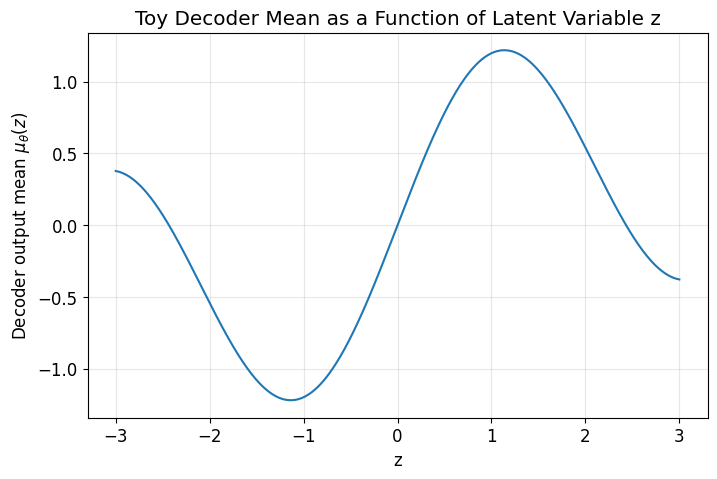

In [39]:
# A simple toy 1D decoder function to illustrate smooth latent structure
z_vals = np.linspace(-3, 3, 400)
decoded_mean = np.sin(1.5 * z_vals) + 0.2 * z_vals

plt.figure()
plt.plot(z_vals, decoded_mean)
plt.title("Toy Decoder Mean as a Function of Latent Variable z")
plt.xlabel("z")
plt.ylabel(r"Decoder output mean $\mu_\theta(z)$")
plt.grid(True, alpha=0.3)
plt.show()

A VAE encourages the latent space to be smooth and structured.

The KL term helps ensure that latent points live in a regular region near the prior, and the decoder learns a smooth mapping from latent space to data space.

This is why nearby latent points often decode to similar outputs.

## 17. Why VAEs Are Generative Models

After training, we can generate new samples without needing an input $x$.

We simply:

1. sample from the prior

   $$
   z \sim p(z) = \mathcal{N}(0, I)
   $$

2. decode

   $$
   x \sim p_\theta(x \mid z)
   $$

or use the decoder mean as the generated sample.

This is possible because the KL term aligned the encoder posteriors with the prior during training.

## 18. Important Practical and Conceptual Notes

### 18.1 Why VAEs can produce blurry outputs

A common reason is the decoder likelihood.  
For example, a Gaussian decoder with independent pixels often encourages averaging across multiple plausible outputs, which can lead to blur.

### 18.2 Posterior collapse

Sometimes the encoder posterior becomes too close to the prior:

$$
q_\phi(z \mid x) \approx p(z)
$$

for all $x$.

Then the latent variable is effectively ignored by the decoder.

This often happens when the decoder is very powerful.

### 18.3 Beta-VAE

A common variant is

$$
\mathcal{L}_\beta
=
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
-
\beta D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
$$

or equivalently the loss

$$
\mathcal{J}_\beta
=
-\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
+
\beta D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
$$

- $\beta > 1$ gives stronger regularization
- $\beta < 1$ gives weaker regularization

## 19. Final Summary

A Variational Autoencoder is a latent variable model with:

- a prior $p(z)$
- an approximate posterior or encoder $q_\phi(z \mid x)$
- a decoder likelihood $p_\theta(x \mid z)$

The true log-likelihood $\log p_\theta(x)$ is generally intractable, so we optimize the ELBO:

$$
\mathcal{L}(x;\theta,\phi)
=
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
-
D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
$$

Training minimizes the negative ELBO:

$$
\mathcal{J}(x;\theta,\phi)
=
-\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
+
D_{\mathrm{KL}}(q_\phi(z \mid x)\|p(z))
$$

The reconstruction term encourages accurate decoding, while the KL term shapes the latent space so that sampling from the prior becomes meaningful.

The reparameterization trick

$$
z = \mu_\phi(x) + \sigma_\phi(x)\odot\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0,I)
$$

makes the whole model trainable by backpropagation.

That is the mathematical core of VAEs.

## From scratch implementation of VAE (Live Code)

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Data
# ----------------------------
def make_pinwheel(points_per_class=700, num_classes=5, radial_std=0.25, tangential_std=0.08, rate=0.35, seed=7):
    rng = np.random.default_rng(seed)
    n = points_per_class * num_classes
    r = rng.normal(loc=1.0, scale=radial_std, size=n)
    t = rng.normal(loc=0.0, scale=tangential_std, size=n)
    labels = np.repeat(np.arange(num_classes), points_per_class)

    base_theta = 2 * np.pi * labels / num_classes
    theta = base_theta + rate * np.exp(r)

    x = np.stack([r * np.cos(theta) - t * np.sin(theta),
                  r * np.sin(theta) + t * np.cos(theta)], axis=1)
    x *= 2.5
    x += 0.03 * rng.normal(size=x.shape)
    return x.astype(np.float64), labels

# ----------------------------
# Init / layers
# ----------------------------
def glorot(in_dim, out_dim, rng):
    s = np.sqrt(2.0 / (in_dim + out_dim))
    return rng.normal(scale=s, size=(in_dim, out_dim))

def init_vae(input_dim=2, hidden_dim=64, latent_dim=2, seed=42):
    rng = np.random.default_rng(seed)
    p = {}
    # encoder
    p["W1e"] = glorot(input_dim, hidden_dim, rng); p["b1e"] = np.zeros(hidden_dim)
    p["W2e"] = glorot(hidden_dim, hidden_dim, rng); p["b2e"] = np.zeros(hidden_dim)
    p["Wmu"] = glorot(hidden_dim, latent_dim, rng); p["bmu"] = np.zeros(latent_dim)
    p["Wlv"] = glorot(hidden_dim, latent_dim, rng); p["blv"] = np.zeros(latent_dim)
    # decoder
    p["W1d"] = glorot(latent_dim, hidden_dim, rng); p["b1d"] = np.zeros(hidden_dim)
    p["W2d"] = glorot(hidden_dim, hidden_dim, rng); p["b2d"] = np.zeros(hidden_dim)
    p["Wout"] = glorot(hidden_dim, input_dim, rng); p["bout"] = np.zeros(input_dim)
    return p

def tanh(x):
    return np.tanh(x)

def affine(x, W, b):
    return x @ W + b

# ----------------------------
# Encoder / decoder
# ----------------------------
def encode(X, p):
    a1 = affine(X, p["W1e"], p["b1e"]); h1 = tanh(a1)
    a2 = affine(h1, p["W2e"], p["b2e"]); h2 = tanh(a2)
    mu = affine(h2, p["Wmu"], p["bmu"])
    logvar = affine(h2, p["Wlv"], p["blv"])
    cache = (X, a1, h1, a2, h2, mu, logvar)
    return mu, logvar, cache

def decode(Z, p):
    a1 = affine(Z, p["W1d"], p["b1d"]); h1 = tanh(a1)
    a2 = affine(h1, p["W2d"], p["b2d"]); h2 = tanh(a2)
    xhat = affine(h2, p["Wout"], p["bout"])
    cache = (Z, a1, h1, a2, h2, xhat)
    return xhat, cache

# ----------------------------
# One forward/backward pass
# ----------------------------
def vae_step(X, p, rng, beta=1.0, sigma2=0.03):
    B = X.shape[0]

    # forward encoder
    mu, logvar, ec = encode(X, p)
    std = np.exp(0.5 * logvar)
    eps = rng.normal(size=mu.shape)
    z = mu + std * eps

    # forward decoder
    xhat, dc = decode(z, p)

    # losses (mean over batch)
    recon = 0.5 / sigma2 * np.mean(np.sum((xhat - X) ** 2, axis=1))
    kl = 0.5 * np.mean(np.sum(np.exp(logvar) + mu**2 - 1.0 - logvar, axis=1))
    loss = recon + beta * kl

    grads = {k: np.zeros_like(v) for k, v in p.items()}

    # ---------------- decoder backward ----------------
    Z, da1, dh1, da2, dh2, XH = dc
    dXH = (xhat - X) / (sigma2 * B)

    grads["Wout"] = dh2.T @ dXH
    grads["bout"] = dXH.sum(axis=0)
    d_h2 = dXH @ p["Wout"].T

    d_a2 = d_h2 * (1.0 - dh2**2)
    grads["W2d"] = dh1.T @ d_a2
    grads["b2d"] = d_a2.sum(axis=0)
    d_h1 = d_a2 @ p["W2d"].T

    d_a1 = d_h1 * (1.0 - dh1**2)
    grads["W1d"] = Z.T @ d_a1
    grads["b1d"] = d_a1.sum(axis=0)
    d_z = d_a1 @ p["W1d"].T

    # ---------------- encoder backward ----------------
    X0, ea1, eh1, ea2, eh2, MU, LV = ec

    d_mu = d_z + beta * (mu / B)
    d_logvar = d_z * (0.5 * std * eps) + beta * (0.5 * (np.exp(logvar) - 1.0) / B)

    grads["Wmu"] = eh2.T @ d_mu
    grads["bmu"] = d_mu.sum(axis=0)
    grads["Wlv"] = eh2.T @ d_logvar
    grads["blv"] = d_logvar.sum(axis=0)

    d_h2e = d_mu @ p["Wmu"].T + d_logvar @ p["Wlv"].T
    d_a2e = d_h2e * (1.0 - eh2**2)

    grads["W2e"] = eh1.T @ d_a2e
    grads["b2e"] = d_a2e.sum(axis=0)
    d_h1e = d_a2e @ p["W2e"].T

    d_a1e = d_h1e * (1.0 - eh1**2)
    grads["W1e"] = X0.T @ d_a1e
    grads["b1e"] = d_a1e.sum(axis=0)

    return loss, recon, kl, grads

# ----------------------------
# Adam
# ----------------------------
def init_adam(params):
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}
    return m, v

def adam_step(params, grads, m, v, t, lr=3e-3, b1=0.9, b2=0.999, eps=1e-8):
    for k in params:
        m[k] = b1 * m[k] + (1 - b1) * grads[k]
        v[k] = b2 * v[k] + (1 - b2) * (grads[k] ** 2)
        mhat = m[k] / (1 - b1**t)
        vhat = v[k] / (1 - b2**t)
        params[k] -= lr * mhat / (np.sqrt(vhat) + eps)

# ----------------------------
# Train / inference utils
# ----------------------------
def train_vae(X, params, epochs=2500, batch_size=256, lr=3e-3, beta=1.0, sigma2=0.03, seed=123):
    rng = np.random.default_rng(seed)
    m, v = init_adam(params)
    n = len(X)
    hist = {"loss": [], "recon": [], "kl": []}
    t = 0

    for epoch in range(epochs):
        idx = rng.permutation(n)
        Xs = X[idx]
        loss_sum = recon_sum = kl_sum = 0.0
        batches = 0

        for i in range(0, n, batch_size):
            xb = Xs[i:i+batch_size]
            t += 1
            loss, recon, kl, grads = vae_step(xb, params, rng, beta=beta, sigma2=sigma2)
            adam_step(params, grads, m, v, t, lr=lr)
            loss_sum += loss; recon_sum += recon; kl_sum += kl
            batches += 1

        hist["loss"].append(loss_sum / batches)
        hist["recon"].append(recon_sum / batches)
        hist["kl"].append(kl_sum / batches)

    return hist

def encode_mean(X, p):
    mu, logvar, _ = encode(X, p)
    return mu, logvar

def decode_mean(Z, p):
    xhat, _ = decode(Z, p)
    return xhat

def nearest_dist_to_cloud(point, cloud):
    return np.min(np.linalg.norm(cloud - point, axis=1))

Starting VAE training...
Dataset size: 4000
Epochs: 2600, Batch size: 256, Learning rate: 0.003, beta: 0.25, sigma2: 0.03
------------------------------------------------------------------------------------------
Epoch    1/2600 | Total Loss:    50.7059 | Recon:    49.8169 | KL:   3.5561
Epoch  200/2600 | Total Loss:     1.8016 | Recon:     0.3068 | KL:   5.9793
Epoch  400/2600 | Total Loss:     1.7483 | Recon:     0.2692 | KL:   5.9165
Epoch  600/2600 | Total Loss:     1.7470 | Recon:     0.3017 | KL:   5.7812
Epoch  800/2600 | Total Loss:     1.6717 | Recon:     0.3027 | KL:   5.4758
Epoch 1000/2600 | Total Loss:     1.6301 | Recon:     0.3063 | KL:   5.2953
Epoch 1200/2600 | Total Loss:     1.5969 | Recon:     0.2831 | KL:   5.2550
Epoch 1400/2600 | Total Loss:     1.5814 | Recon:     0.3172 | KL:   5.0568
Epoch 1600/2600 | Total Loss:     1.5931 | Recon:     0.3091 | KL:   5.1360
Epoch 1800/2600 | Total Loss:     1.5592 | Recon:     0.3085 | KL:   5.0028
Epoch 2000/2600 | Total Los

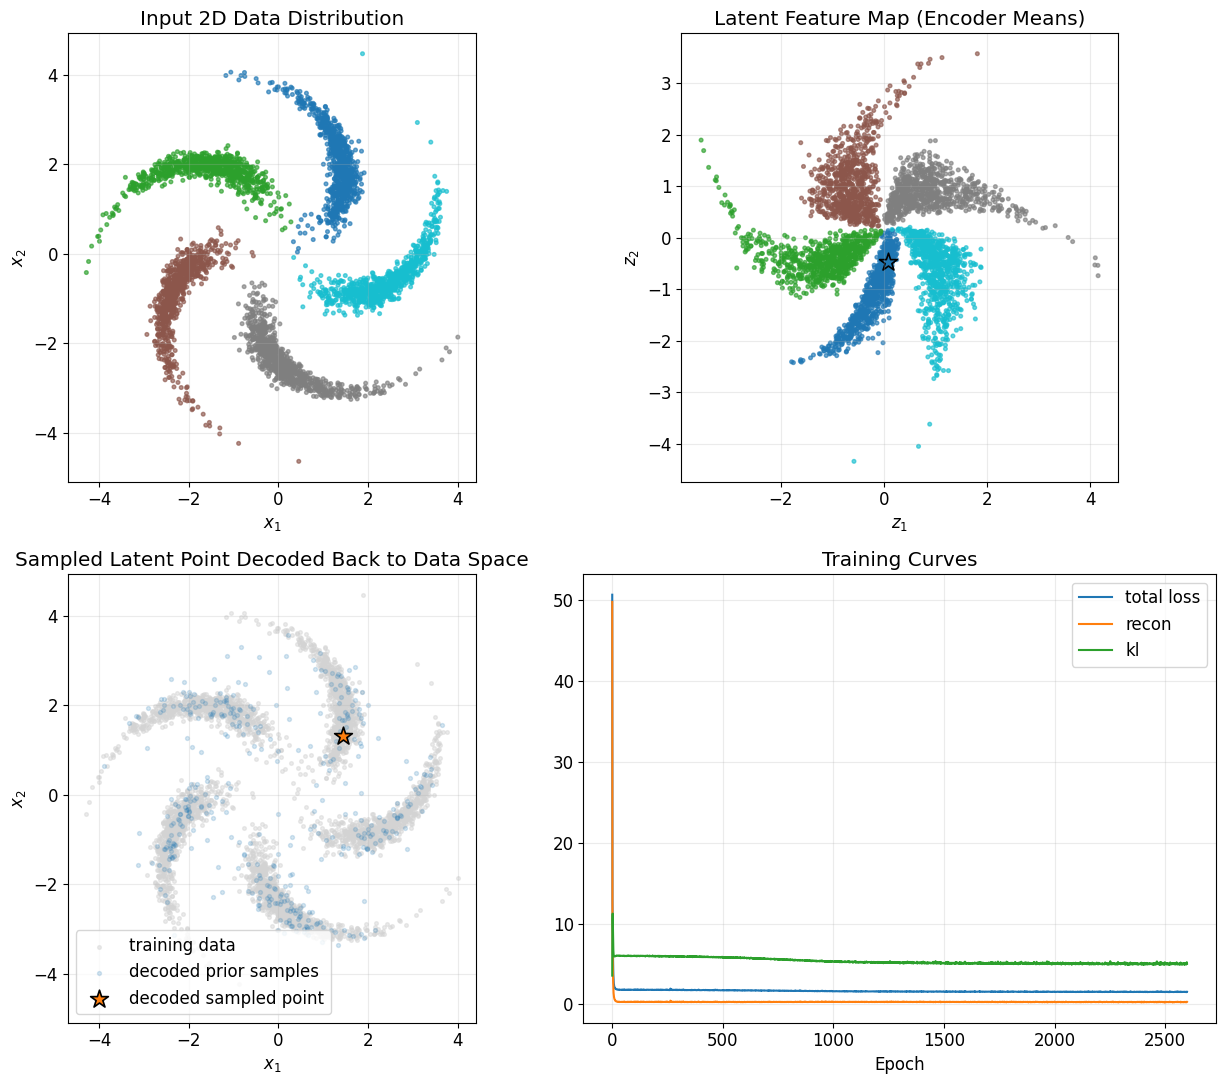


Final sampled result:
Sampled latent point z* = [ 0.0825 -0.4644]
Decoded data point x*   = [1.4418 1.3221]
Distance to nearest training point = 0.0198


In [42]:
# ----------------------------
# Run everything
# ----------------------------
X, y = make_pinwheel(points_per_class=800, num_classes=5, seed=10)

params = init_vae(input_dim=2, hidden_dim=64, latent_dim=2, seed=1)

# Train with visible progress
epochs = 2600
batch_size = 256
lr = 3e-3
beta = 0.25
sigma2 = 0.03
seed = 11

rng_train = np.random.default_rng(seed)
m, v = init_adam(params)
n = len(X)
hist = {"loss": [], "recon": [], "kl": []}
t = 0

print("Starting VAE training...")
print(f"Dataset size: {n}")
print(f"Epochs: {epochs}, Batch size: {batch_size}, Learning rate: {lr}, beta: {beta}, sigma2: {sigma2}")
print("-" * 90)

for epoch in range(epochs):
    idx = rng_train.permutation(n)
    Xs = X[idx]
    loss_sum = recon_sum = kl_sum = 0.0
    batches = 0

    for i in range(0, n, batch_size):
        xb = Xs[i:i+batch_size]
        t += 1
        loss, recon, kl, grads = vae_step(xb, params, rng_train, beta=beta, sigma2=sigma2)
        adam_step(params, grads, m, v, t, lr=lr)
        loss_sum += loss
        recon_sum += recon
        kl_sum += kl
        batches += 1

    epoch_loss = loss_sum / batches
    epoch_recon = recon_sum / batches
    epoch_kl = kl_sum / batches

    hist["loss"].append(epoch_loss)
    hist["recon"].append(epoch_recon)
    hist["kl"].append(epoch_kl)

    if epoch == 0 or (epoch + 1) % 200 == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch + 1:4d}/{epochs} | "
            f"Total Loss: {epoch_loss:10.4f} | "
            f"Recon: {epoch_recon:10.4f} | "
            f"KL: {epoch_kl:8.4f}"
        )

print("-" * 90)
print("Training complete.")

# Encode dataset into latent means
mu, logvar = encode_mean(X, params)

# Sample from prior until we get a decoded point that lies close to the learned data cloud
rng = np.random.default_rng(99)
z_new, x_new = None, None
best_z, best_x, best_d = None, None, 1e9

for _ in range(300):
    z_try = rng.normal(size=(1, 2))
    x_try = decode_mean(z_try, params)
    d = nearest_dist_to_cloud(x_try[0], X)
    if d < best_d:
        best_d, best_z, best_x = d, z_try, x_try
    if d < 0.18:
        z_new, x_new = z_try, x_try
        break

if z_new is None:
    z_new, x_new = best_z, best_x

# A few additional generated samples for context
Z_gen = rng.normal(size=(400, 2))
X_gen = decode_mean(Z_gen, params)

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# 1) input distribution
axes[0, 0].scatter(X[:, 0], X[:, 1], c=y, s=7, alpha=0.65, cmap="tab10")
axes[0, 0].set_title("Input 2D Data Distribution")
axes[0, 0].set_xlabel(r"$x_1$")
axes[0, 0].set_ylabel(r"$x_2$")
axes[0, 0].grid(True, alpha=0.25)
axes[0, 0].set_aspect("equal")

# 2) latent feature map
axes[0, 1].scatter(mu[:, 0], mu[:, 1], c=y, s=7, alpha=0.65, cmap="tab10")
axes[0, 1].scatter(z_new[0, 0], z_new[0, 1], s=180, marker="*", edgecolor="black", linewidth=1.2)
axes[0, 1].set_title("Latent Feature Map (Encoder Means)")
axes[0, 1].set_xlabel(r"$z_1$")
axes[0, 1].set_ylabel(r"$z_2$")
axes[0, 1].grid(True, alpha=0.25)
axes[0, 1].set_aspect("equal")

# 3) decoded sample overlaid on data
axes[1, 0].scatter(X[:, 0], X[:, 1], c="lightgray", s=7, alpha=0.45, label="training data")
axes[1, 0].scatter(X_gen[:, 0], X_gen[:, 1], s=8, alpha=0.18, label="decoded prior samples")
axes[1, 0].scatter(
    x_new[0, 0], x_new[0, 1],
    s=180, marker="*", edgecolor="black", linewidth=1.2,
    label="decoded sampled point"
)
axes[1, 0].set_title("Sampled Latent Point Decoded Back to Data Space")
axes[1, 0].set_xlabel(r"$x_1$")
axes[1, 0].set_ylabel(r"$x_2$")
axes[1, 0].grid(True, alpha=0.25)
axes[1, 0].legend(loc="best")
axes[1, 0].set_aspect("equal")

# 4) training curves
axes[1, 1].plot(hist["loss"], label="total loss")
axes[1, 1].plot(hist["recon"], label="recon")
axes[1, 1].plot(hist["kl"], label="kl")
axes[1, 1].set_title("Training Curves")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].grid(True, alpha=0.25)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nFinal sampled result:")
print("Sampled latent point z* =", np.round(z_new[0], 4))
print("Decoded data point x*   =", np.round(x_new[0], 4))
print("Distance to nearest training point =", round(nearest_dist_to_cloud(x_new[0], X), 4))

## VAE 3D Visualization

In [66]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import os
from IPython.display import IFrame, display

# ============================================================
# Render mode
# ============================================================
render_mode = "iframe"   # "iframe" or "vscode"

if render_mode == "vscode":
    pio.renderers.default = "vscode"
else:
    pio.renderers.default = "iframe"

def show_plotly_figure(fig, filename="vae_3d_default_zoom_with_spacing.html", height=760):
    if render_mode == "iframe":
        folder = "iframe_figures"
        os.makedirs(folder, exist_ok=True)
        path = os.path.join(folder, filename)
        fig.write_html(
            path,
            include_plotlyjs="cdn",
            full_html=True,
            auto_play=False,
            config={"scrollZoom": True, "displaylogo": False, "responsive": True}
        )
        display(IFrame(src=path, width="100%", height=str(height)))
    else:
        fig.show(config={"scrollZoom": True, "displaylogo": False, "responsive": True})

# ============================================================
# Synthetic pedagogical VAE-like setup in 3D
# ============================================================
rng = np.random.default_rng(7)

def decoder(Z):
    Z = np.atleast_2d(Z)
    z1, z2, z3 = Z[:, 0], Z[:, 1], Z[:, 2]
    t = 2.9 * np.tanh(0.85 * z1) + 0.55 * np.sin(1.1 * z2)
    r = 1.25 + 0.30 * np.tanh(1.2 * z2)
    x = 1.1 * t
    y = r * np.sin(1.55 * t) + 0.45 * z3 + 0.12 * np.sin(2.2 * z2)
    z = r * np.cos(1.55 * t) + 0.28 * z3 + 0.18 * np.sin(1.4 * z2)
    return np.stack([x, y, z], axis=1)

n_points = 1400
latent_means = rng.normal(size=(n_points, 3))
data_points = decoder(latent_means)
color_val = latent_means[:, 0]

idx = 230
mu = latent_means[idx].copy()
x_input = data_points[idx].copy()

std = np.array([0.40, 0.24, 0.32])
direction = np.array([2.8, -2.1, 1.7])
alphas = np.linspace(-1.15, 1.65, 72)
z_path = mu + std * (alphas[:, None] * direction[None, :])
xhat_path = decoder(z_path)

def sphere_surface(radius=2.8, n_phi=38, n_theta=76):
    phi = np.linspace(0, np.pi, n_phi)
    theta = np.linspace(0, 2 * np.pi, n_theta)
    phi_grid, theta_grid = np.meshgrid(phi, theta)
    xs = radius * np.sin(phi_grid) * np.cos(theta_grid)
    ys = radius * np.sin(phi_grid) * np.sin(theta_grid)
    zs = radius * np.cos(phi_grid)
    return xs, ys, zs

prior_x, prior_y, prior_z = sphere_surface()

def ellipsoid_surface(mean, std, n_std=2.0, n_phi=32, n_theta=64):
    phi = np.linspace(0, np.pi, n_phi)
    theta = np.linspace(0, 2 * np.pi, n_theta)
    phi_grid, theta_grid = np.meshgrid(phi, theta)
    ex = n_std * std[0] * np.sin(phi_grid) * np.cos(theta_grid) + mean[0]
    ey = n_std * std[1] * np.sin(phi_grid) * np.sin(theta_grid) + mean[1]
    ez = n_std * std[2] * np.cos(phi_grid) + mean[2]
    return ex, ey, ez

post_x, post_y, post_z = ellipsoid_surface(mu, std, n_std=2.0)

def padded_range(v, pad_frac=0.10, min_pad=0.35):
    vmin, vmax = float(np.min(v)), float(np.max(v))
    span = vmax - vmin
    pad = max(min_pad, pad_frac * span if span > 1e-8 else min_pad)
    return [vmin - pad, vmax + pad]

# Keep the current tighter / zoomed-in view as default
x_range = padded_range(np.concatenate([data_points[:, 0], xhat_path[:, 0]]), 0.08, 0.40)
y_range = padded_range(np.concatenate([data_points[:, 1], xhat_path[:, 1]]), 0.08, 0.40)
z_range = padded_range(np.concatenate([data_points[:, 2], xhat_path[:, 2]]), 0.08, 0.40)

lz1_range = padded_range(np.concatenate([latent_means[:, 0], z_path[:, 0], post_x.ravel()]), 0.10, 0.50)
lz2_range = padded_range(np.concatenate([latent_means[:, 1], z_path[:, 1], post_y.ravel()]), 0.10, 0.50)
lz3_range = padded_range(np.concatenate([latent_means[:, 2], z_path[:, 2], post_z.ravel()]), 0.10, 0.50)

right_focus = np.vstack([x_input[None, :], xhat_path, data_points[:140]])
rx_range = padded_range(right_focus[:, 0], 0.06, 0.28)
ry_range = padded_range(right_focus[:, 1], 0.06, 0.28)
rz_range = padded_range(right_focus[:, 2], 0.06, 0.28)

# ============================================================
# Build figure
# ============================================================
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "scene"}, {"type": "scene"}, {"type": "scene"}]],
    subplot_titles=(
        "1. Data Distribution and Input x",
        "2. Latent Space and Posterior q(z|x)",
        "3. Decoding: z → x_hat"
    ),
    horizontal_spacing=0.0
)

trace_ids = {}

# Panel 1
trace_ids["data_cloud_1"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=data_points[:, 0], y=data_points[:, 1], z=data_points[:, 2],
        mode="markers",
        marker=dict(
            size=3.2,
            color=color_val,
            colorscale="Viridis",
            opacity=0.34,
            colorbar=dict(
                title="latent z1",
                len=0.42,
                x=0.334,
                y=0.54,
                thickness=12
            )
        ),
        name="Data distribution",
        showlegend=True
    ),
    row=1, col=1
)

trace_ids["input_x_1"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=[x_input[0]], y=[x_input[1]], z=[x_input[2]],
        mode="markers+text",
        marker=dict(size=8, color="royalblue", symbol="diamond"),
        text=["x"],
        textposition="top center",
        name="Input x",
        showlegend=True
    ),
    row=1, col=1
)

# Panel 2
trace_ids["prior_surface"] = len(fig.data)
fig.add_trace(
    go.Surface(
        x=prior_x, y=prior_y, z=prior_z,
        opacity=0.10,
        showscale=False,
        colorscale=[[0, "rgb(180,225,255)"], [1, "rgb(180,225,255)"]],
        name="Prior p(z)",
        showlegend=True
    ),
    row=1, col=2
)

trace_ids["latent_cloud"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=latent_means[:, 0], y=latent_means[:, 1], z=latent_means[:, 2],
        mode="markers",
        marker=dict(size=3.0, color=color_val, colorscale="Viridis", opacity=0.52, showscale=False),
        name="Encoded means",
        showlegend=True
    ),
    row=1, col=2
)

trace_ids["posterior_surface"] = len(fig.data)
fig.add_trace(
    go.Surface(
        x=post_x, y=post_y, z=post_z,
        opacity=0.28,
        showscale=False,
        colorscale=[[0, "orange"], [1, "orange"]],
        name="Posterior q(z|x)",
        showlegend=True
    ),
    row=1, col=2
)

trace_ids["posterior_mean"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=[mu[0]], y=[mu[1]], z=[mu[2]],
        mode="markers+text",
        marker=dict(size=7, color="darkorange", symbol="diamond"),
        text=["mu(x)"],
        textposition="top center",
        name="Posterior mean",
        showlegend=True
    ),
    row=1, col=2
)

trace_ids["latent_sample"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=[z_path[0, 0]], y=[z_path[0, 1]], z=[z_path[0, 2]],
        mode="markers+text",
        marker=dict(size=8, color="purple", symbol="diamond-open"),
        text=["z"],
        textposition="top center",
        name="Sampled latent z",
        showlegend=True
    ),
    row=1, col=2
)

trace_ids["latent_path"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=[z_path[0, 0]], y=[z_path[0, 1]], z=[z_path[0, 2]],
        mode="lines",
        line=dict(color="purple", width=8),
        name="Sampling path",
        showlegend=True
    ),
    row=1, col=2
)

# Panel 3
trace_ids["data_cloud_3"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=data_points[:, 0], y=data_points[:, 1], z=data_points[:, 2],
        mode="markers",
        marker=dict(size=3.0, color=color_val, colorscale="Viridis", opacity=0.14, showscale=False),
        name="Data manifold",
        showlegend=False
    ),
    row=1, col=3
)

trace_ids["input_x_3"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=[x_input[0]], y=[x_input[1]], z=[x_input[2]],
        mode="markers+text",
        marker=dict(size=7, color="royalblue", symbol="diamond"),
        text=["x"],
        textposition="top center",
        name="Original x",
        showlegend=False
    ),
    row=1, col=3
)

trace_ids["decoded_xhat"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=[xhat_path[0, 0]], y=[xhat_path[0, 1]], z=[xhat_path[0, 2]],
        mode="markers+text",
        marker=dict(size=8, color="crimson", symbol="diamond-open"),
        text=["x_hat"],
        textposition="top center",
        name="Decoded x_hat",
        showlegend=True
    ),
    row=1, col=3
)

trace_ids["decoded_path"] = len(fig.data)
fig.add_trace(
    go.Scatter3d(
        x=[xhat_path[0, 0]], y=[xhat_path[0, 1]], z=[xhat_path[0, 2]],
        mode="lines",
        line=dict(color="crimson", width=8),
        name="Decoded path",
        showlegend=True
    ),
    row=1, col=3
)

# ============================================================
# Animation frames
# ============================================================
frames = []
for t in range(len(z_path)):
    frames.append(
        go.Frame(
            name=str(t),
            data=[
                go.Scatter3d(
                    x=[z_path[t, 0]], y=[z_path[t, 1]], z=[z_path[t, 2]],
                    mode="markers+text",
                    marker=dict(size=8, color="purple", symbol="diamond-open"),
                    text=["z"],
                    textposition="top center"
                ),
                go.Scatter3d(
                    x=z_path[:t+1, 0], y=z_path[:t+1, 1], z=z_path[:t+1, 2],
                    mode="lines",
                    line=dict(color="purple", width=8)
                ),
                go.Scatter3d(
                    x=[xhat_path[t, 0]], y=[xhat_path[t, 1]], z=[xhat_path[t, 2]],
                    mode="markers+text",
                    marker=dict(size=8, color="crimson", symbol="diamond-open"),
                    text=["x_hat"],
                    textposition="top center"
                ),
                go.Scatter3d(
                    x=xhat_path[:t+1, 0], y=xhat_path[:t+1, 1], z=xhat_path[:t+1, 2],
                    mode="lines",
                    line=dict(color="crimson", width=8)
                ),
            ],
            traces=[
                trace_ids["latent_sample"],
                trace_ids["latent_path"],
                trace_ids["decoded_xhat"],
                trace_ids["decoded_path"],
            ]
        )
    )
fig.frames = frames

# ============================================================
# Controls
# ============================================================
sliders = [
    dict(
        active=0,
        x=0.24,
        y=0.035,
        len=0.52,
        pad=dict(t=0, b=8),   # add space after scroller
        currentvalue=dict(prefix="Frame: ", font=dict(size=13)),
        steps=[
            dict(
                method="animate",
                args=[[str(i)], dict(mode="immediate", frame=dict(duration=0, redraw=True), transition=dict(duration=0))],
                label=str(i)
            )
            for i in range(len(z_path))
        ]
    )
]

common_scene = dict(
    aspectmode="cube",
    camera=dict(eye=dict(x=1.42, y=1.30, z=1.10))
)

scene1_domain = dict(x=[0.00, 0.327], y=[0.17, 0.84])
scene2_domain = dict(x=[0.336, 0.664], y=[0.17, 0.84])
scene3_domain = dict(x=[0.673, 1.00], y=[0.17, 0.84])

fig.update_layout(
    title=dict(
        text="VAE Process in 3D: data x → encode to q(z|x) → sample z → decode to x_hat",
        x=0.5, xanchor="center", y=0.995, font=dict(size=17)
    ),
    autosize=True,
    height=720,
    margin=dict(
        l=4, r=4,
        t=50,   # add space before legends
        b=58    # add more space after scroller
    ),
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=0.965,   # lower legend slightly to create spacing from title
        xanchor="center",
        x=0.5,
        bgcolor="rgba(255,255,255,0.72)",
        font=dict(size=12),
        itemsizing="constant"
    ),
    sliders=sliders,
    updatemenus=[
        dict(
            type="buttons",
            direction="left",
            x=0.5,
            y=0.088,
            xanchor="center",
            yanchor="bottom",
            showactive=False,
            pad=dict(r=4, t=0),
            buttons=[
                dict(
                    label="▶ Play",
                    method="animate",
                    args=[None, dict(frame=dict(duration=50, redraw=True), transition=dict(duration=0), fromcurrent=True, mode="immediate")]
                ),
                dict(
                    label="⏸ Pause",
                    method="animate",
                    args=[[None], dict(frame=dict(duration=0, redraw=True), transition=dict(duration=0), mode="immediate")]
                )
            ]
        )
    ],
    scene=dict(
        **common_scene,
        domain=scene1_domain,
        xaxis=dict(visible=False, range=x_range),
        yaxis=dict(visible=False, range=y_range),
        zaxis=dict(visible=False, range=z_range),
    ),
    scene2=dict(
        **common_scene,
        domain=scene2_domain,
        xaxis=dict(visible=False, range=lz1_range),
        yaxis=dict(visible=False, range=lz2_range),
        zaxis=dict(visible=False, range=lz3_range),
    ),
    scene3=dict(
        **common_scene,
        domain=scene3_domain,
        xaxis=dict(visible=False, range=rx_range),
        yaxis=dict(visible=False, range=ry_range),
        zaxis=dict(visible=False, range=rz_range),
    ),
)

for ann in fig.layout.annotations:
    ann.y = 0.90
    ann.font = dict(size=15)

show_plotly_figure(fig, filename="vae_3d_default_zoom_with_spacing.html", height=760)